# Minería de Datos - Clase 5: Ejercitación

En este notebook se resuelven ejercicios prácticos de limpieza y transformación de datos correspondientes a la Clase 5.

Se trabajan tres partes:
1. Manejo de valores faltantes con el dataset Titanic.
2. Detección de outliers con el dataset Diamonds.
3. Normalización y codificación de variables categóricas con Titanic.

In [1]:
# Importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

## Ejercicio 1: Manejo de valores faltantes con Titanic

En esta primera parte se trabaja con el dataset Titanic. El objetivo es identificar valores nulos, eliminar los registros sin edad e imputar los valores faltantes de la columna embark_town utilizando la moda.

In [2]:
# Cargar dataset Titanic

df_titanic = sns.load_dataset("titanic")

# Mostrar primeras filas
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


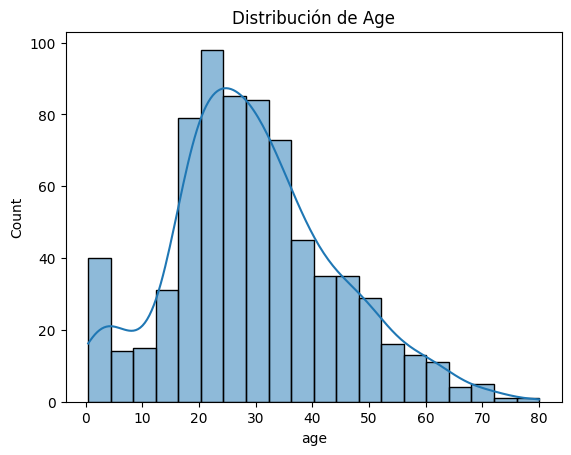

In [10]:
# Histograma de Age

sns.histplot(df_titanic["age"], kde=True)

plt.title("Distribución de Age")

plt.show()

La distribución de la variable “Age” presenta cierto sesgo, por lo que la mediana resulta una estrategia adecuada para imputar valores faltantes.

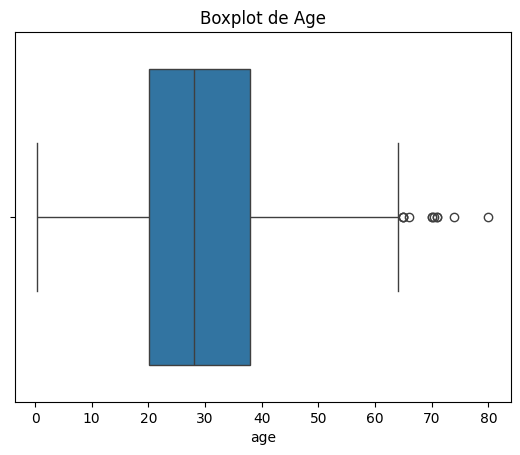

In [11]:
# Boxplot de Age

sns.boxplot(x=df_titanic["age"])

plt.title("Boxplot de Age")

plt.show()

El boxplot permitió visualizar la dispersión de la variable “Age” y detectar posibles valores atípicos dentro del dataset.

### Identificación de valores faltantes

Se analizaron las columnas del dataset Titanic para detectar la presencia de valores nulos. Esto es importante porque los datos faltantes pueden afectar el análisis y el rendimiento de los modelos de minería de datos.

In [3]:
# Verificar valores nulos

df_titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Se observó que algunas columnas presentan valores faltantes, especialmente “age”, “deck” y “embark_town”.

En este ejercicio se trabajará principalmente con la columna “age” y “embark_town” para aplicar técnicas básicas de limpieza de datos.

In [4]:
# Eliminar filas con edad nula

df_sin_null = df_titanic.dropna(subset=["age"])

# Mostrar dimensiones antes y después

print("Filas originales:", len(df_titanic))
print("Filas luego de eliminar edades nulas:", len(df_sin_null))

Filas originales: 891
Filas luego de eliminar edades nulas: 714


### Imputación de valores faltantes

Luego se trabajó con la columna “embark_town”. Para completar los valores faltantes se utilizó la moda, es decir, el valor que más se repite dentro de la columna.

La imputación es una técnica utilizada para evitar la pérdida de registros y mantener la estructura del dataset.

In [5]:
# Imputar valores faltantes con la moda

moda = df_titanic["embark_town"].mode()[0]

df_titanic["embark_town"] = df_titanic["embark_town"].fillna(moda)

# Verificar valores nulos restantes

df_titanic["embark_town"].isnull().sum()

np.int64(0)

Después de aplicar la imputación utilizando la moda, la columna “embark_town” ya no presenta valores faltantes.

Esta técnica es útil cuando se trabaja con variables categóricas y se desea conservar la mayor cantidad posible de registros.

## Ejercicio 2: Detección de outliers con Diamonds

En esta parte se utiliza el dataset Diamonds para detectar valores atípicos en la variable “price”.

Los outliers son valores extremadamente altos o bajos que pueden afectar el análisis y el comportamiento de algunos algoritmos de minería de datos.

In [6]:
# Cargar dataset Diamonds

df_diamonds = sns.load_dataset("diamonds")

# Mostrar primeras filas

df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Se trabajará con la variable “price” para analizar la presencia de posibles valores atípicos utilizando un boxplot.

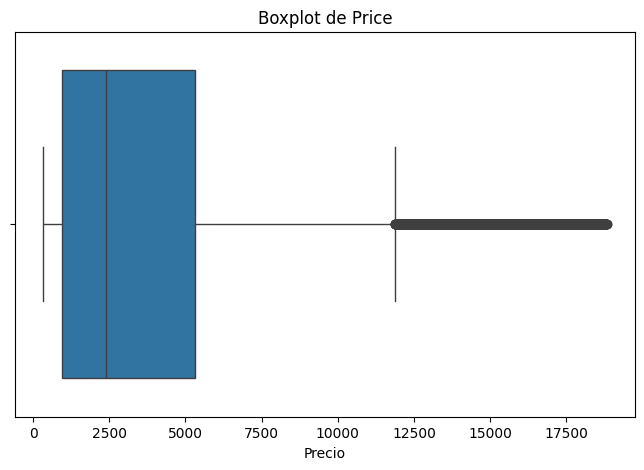

In [7]:
# Boxplot de precios

plt.figure(figsize=(8,5))

sns.boxplot(x=df_diamonds["price"])

plt.title("Boxplot de Price")
plt.xlabel("Precio")

plt.show()

En el boxplot se observan múltiples valores atípicos en la variable “price”.

Esto ocurre porque existen diamantes con precios considerablemente más altos que la mayoría de los registros del dataset.

### Aplicación del método IQR

Luego de visualizar los outliers con el boxplot, se aplicó el método IQR para calcular los límites inferior y superior de la variable “price” y filtrar los valores atípicos.

In [8]:
# Aplicar método IQR en la variable price

Q1 = df_diamonds["price"].quantile(0.25)
Q3 = df_diamonds["price"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_diamonds_cleaned = df_diamonds[
    (df_diamonds["price"] >= limite_inferior) &
    (df_diamonds["price"] <= limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

print("Cantidad de registros antes:", len(df_diamonds))
print("Cantidad de registros después:", len(df_diamonds_cleaned))

Q1: 950.0
Q3: 5324.25
IQR: 4374.25
Límite inferior: -5611.375
Límite superior: 11885.625
Cantidad de registros antes: 53940
Cantidad de registros después: 50400


Después de aplicar el método IQR, se eliminaron los valores de “price” que estaban fuera de los límites calculados. Esto permite trabajar con una distribución más controlada y reducir el impacto de valores extremos en el análisis.

## Ejercicio 3: Normalización y codificación con Titanic

En este ejercicio se vuelve a utilizar el dataset Titanic para aplicar transformación de datos numéricos y categóricos.

El objetivo es normalizar la columna “fare” utilizando Min-Max Scaling y transformar la variable “sex” mediante One-Hot Encoding.

In [9]:
# Cargar nuevamente el dataset Titanic

df_titanic_transformado = sns.load_dataset("titanic")

# Normalizar la columna fare con Min-Max Scaling

scaler = MinMaxScaler()

df_titanic_transformado["fare_normalizado"] = scaler.fit_transform(
    df_titanic_transformado[["fare"]]
)

# Aplicar One-Hot Encoding a la columna sex

df_titanic_transformado = pd.get_dummies(
    df_titanic_transformado,
    columns=["sex"],
    prefix="Sexo"
)

# Mostrar resultado

df_titanic_transformado[["fare", "fare_normalizado", "Sexo_female", "Sexo_male"]].head()

,fare,fare_normalizado,Sexo_female,Sexo_male
0,7.2500,0.014151,False,True
1,71.2833,0.139136,True,False
2,7.9250,0.015469,True,False
3,53.1000,0.103644,True,False
4,8.0500,0.015713,False,True


La normalización permitió transformar los valores de “fare” a una escala entre 0 y 1. Esto facilita la comparación de los datos y evita que los valores con mayor magnitud tengan un peso excesivo en el análisis.

Por otro lado, One-Hot Encoding permitió convertir la variable categórica “sex” en columnas binarias. De esta manera, los datos quedan preparados para ser utilizados en procesos posteriores de análisis dentro de Minería de Datos.

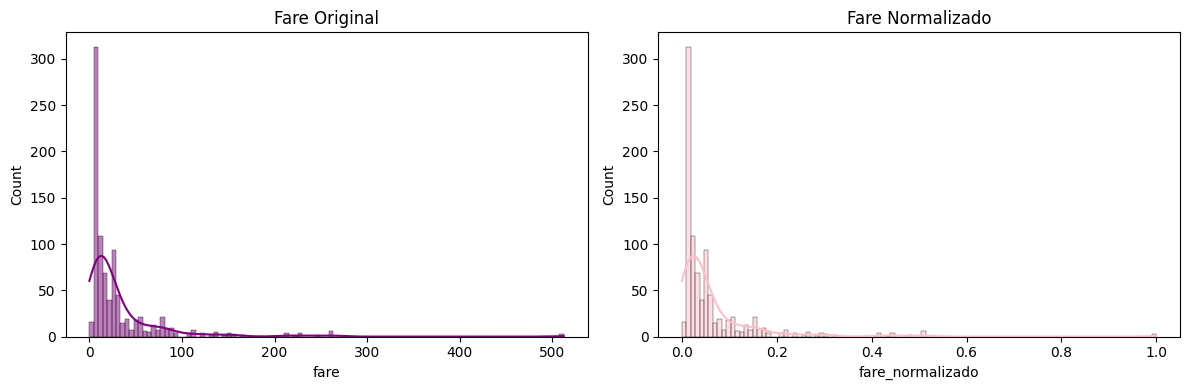

In [12]:
# Comparación antes y después de normalizar

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(
    df_titanic_transformado["fare"],
    kde=True,
    ax=axes[0],
    color="purple"
)

axes[0].set_title("Fare Original")

sns.histplot(
    df_titanic_transformado["fare_normalizado"],
    kde=True,
    ax=axes[1],
    color="pink"
)

axes[1].set_title("Fare Normalizado")

plt.tight_layout()

plt.show()

La comparación entre ambos histogramas permite observar cómo la normalización transforma los datos a una escala entre 0 y 1 manteniendo la forma general de la distribución.

## Reflexión final

En esta ejercitación se aplicaron distintas técnicas de preprocesamiento de datos vistas en la Clase 5 de Minería de Datos.

Primero se trabajó con valores faltantes en el dataset Titanic, identificando columnas con datos nulos y aplicando estrategias como la eliminación de registros sin edad y la imputación de valores categóricos mediante la moda.

Luego se analizaron valores atípicos en el dataset Diamonds utilizando un boxplot y el método IQR. Esta técnica permitió detectar y filtrar valores extremos en la variable price.

Finalmente, se aplicaron técnicas de transformación sobre el dataset Titanic. La variable fare fue normalizada con Min-Max Scaling y la variable sex fue transformada mediante One-Hot Encoding.

Estas técnicas son importantes porque permiten mejorar la calidad, consistencia y representación de los datos antes de realizar análisis más avanzados dentro del proceso de Minería de Datos.

## Resumen de técnicas utilizadas

- Identificación de valores nulos con isnull().sum().
- Eliminación de registros con valores faltantes.
- Imputación de variables categóricas utilizando la moda.
- Visualización de distribuciones mediante histogramas.
- Detección de outliers mediante boxplot.
- Cálculo de límites con el método IQR.
- Normalización Min-Max para variables numéricas.
- Codificación One-Hot Encoding para variables categóricas.